# Comprehensive Statistical Analysis of Iteration 2 Results

This notebook demonstrates a rigorous statistical analysis pipeline for comparing tree-based methods
(axis-aligned, random-oblique, and signed-spectral FIGS) across multiple benchmarks.

**Analysis sections:**
- **A.** Friedman/Nemenyi non-parametric ranking tests
- **B.** Cohen's d effect sizes
- **C.** Bayesian signed-rank with bootstrap ROPE
- **D.** Frustration-accuracy Spearman correlation
- **E.** Subsampling noise-floor model
- **F.** Interpretability analysis (split arity & path length)
- **G.** California housing regression anomaly diagnosis
- **H.** Synthetic recovery summary
- **I.** Success criteria evaluation

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# scikit-posthocs — NOT on Colab, always install
_pip('scikit-posthocs==0.11.0')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.15.3', 'matplotlib==3.10.0', 'scikit-learn==1.6.1')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
from collections import defaultdict
from typing import Any, Optional

import numpy as np
from scipy import stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import scikit_posthocs as sp

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter3_comprehensive_s/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"  aggregated_results: {len(data['aggregated_results'])} records")
print(f"  best_max_splits: {len(data['best_max_splits'])} entries")
print(f"  frustration_analysis: {list(data['frustration_analysis'].keys())}")
print(f"  per_variant: {list(data['per_variant'].keys())}")
print(f"  subsampling points: {len(data['subsampling_stability']['results_by_subsample'])}")

Loaded data with keys: ['description', 'aggregated_results', 'best_max_splits', 'frustration_analysis', 'per_variant', 'subsampling_stability', 'total_wallclock_sec']
  aggregated_results: 36 records
  best_max_splits: 9 entries
  frustration_analysis: ['electricity', 'adult', 'california_housing']
  per_variant: ['easy_2mod_xor', 'medium_4mod_mixed', 'hard_4mod_unequal', 'no_structure_control']
  subsampling points: 6


## Configuration

Tunable parameters for the analysis. Bootstrap sample counts are set to minimum values for fast demo execution.

In [5]:
# ── Tunable parameters ──
# Bootstrap iterations
N_BOOTSTRAP = 10000  # original: 10000
ROPE = 0.01  # Region of practical equivalence

# Dataset/method configuration
DATASETS = ["electricity", "adult", "california_housing"]  # original includes jannis, higgs_small
METHODS = ["axis_aligned_figs", "random_oblique_figs", "signed_spectral_figs"]
METHOD_SHORT = {"axis_aligned_figs": "aa", "random_oblique_figs": "ro", "signed_spectral_figs": "ss"}
MAX_SPLITS_GRID = [5, 10, 15, 20]

# Synthetic experiment configuration
SYNTHETIC_VARIANTS_STRUCTURED = ["easy_2mod_xor", "medium_4mod_mixed", "hard_4mod_unequal"]
SYNTHETIC_METHODS = ["sponge_auto_k", "sponge_oracle_k", "hard_threshold", "unsigned_spectral", "random_partition"]

print("Config loaded.")

Config loaded.


## Helper Functions

Build the performance lookup table from aggregated results and define utility functions.

In [6]:
def get_perf(record: dict) -> tuple:
    """Get (mean, std) performance metric from an aggregated result record."""
    if record["task_type"] == "classification":
        return record["balanced_accuracy_mean"], record["balanced_accuracy_std"]
    else:
        return record["r2_mean"], record["r2_std"]


def build_perf_lookup(agg_results: list) -> dict:
    """Build dict: (dataset, method, max_splits) -> {mean, std, task_type, arity, path_length, fit_time}."""
    lookup = {}
    for r in agg_results:
        mean_val, std_val = get_perf(r)
        key = (r["dataset"], r["method"], r["max_splits"])
        lookup[key] = {
            "mean": mean_val,
            "std": std_val,
            "task_type": r["task_type"],
            "arity": r["avg_split_arity_mean"],
            "path_length": r["avg_path_length_mean"],
            "fit_time": r["fit_time_sec_mean"],
        }
    return lookup


def safe_float(v: Any) -> float:
    """Convert value to float, replacing None/NaN/Inf with sentinel -999.0."""
    if v is None:
        return -999.0
    try:
        f = float(v)
        if np.isnan(f) or np.isinf(f):
            return -999.0
        return f
    except (TypeError, ValueError):
        return -999.0


# Build lookup from data
lookup = build_perf_lookup(data["aggregated_results"])
best_max_splits = data["best_max_splits"]
frustration_analysis = data["frustration_analysis"]
per_variant = data["per_variant"]
stability_data = data["subsampling_stability"]

print(f"Lookup table: {len(lookup)} entries")
print(f"Sample key: {list(lookup.keys())[0]} -> mean={lookup[list(lookup.keys())[0]]['mean']:.4f}")

Lookup table: 36 entries
Sample key: ('electricity', 'axis_aligned_figs', 5) -> mean=0.7323


## A. Friedman / Nemenyi Tests

Non-parametric ranking test across methods at each `max_splits` level. If significant (p < 0.05), Nemenyi post-hoc identifies which pairs differ.

In [7]:
def compute_friedman_nemenyi(lookup, best_max_splits):
    """Compute Friedman + Nemenyi tests at each max_splits level and best-max_splits."""
    results = {}
    n_ds = len(DATASETS)

    def run_friedman(matrix, label):
        try:
            chi2, p_value = stats.friedmanchisquare(
                matrix[:, 0], matrix[:, 1], matrix[:, 2]
            )
        except Exception as e:
            return {"friedman_chi2": -999.0, "friedman_p": -999.0, "error": str(e)}

        ranks = np.zeros_like(matrix)
        for i in range(matrix.shape[0]):
            ranks[i] = stats.rankdata(-matrix[i])
        avg_ranks = ranks.mean(axis=0)

        result = {
            "friedman_chi2": float(chi2),
            "friedman_p": float(p_value),
            "avg_rank_aa": float(avg_ranks[0]),
            "avg_rank_ro": float(avg_ranks[1]),
            "avg_rank_ss": float(avg_ranks[2]),
        }

        if p_value < 0.05:
            try:
                nemenyi = sp.posthoc_nemenyi_friedman(matrix)
                result["nemenyi_aa_vs_ro"] = float(nemenyi.iloc[0, 1])
                result["nemenyi_aa_vs_ss"] = float(nemenyi.iloc[0, 2])
                result["nemenyi_ro_vs_ss"] = float(nemenyi.iloc[1, 2])
            except Exception as e:
                print(f"  Nemenyi failed for {label}: {e}")
        return result

    for ms in MAX_SPLITS_GRID:
        matrix = np.zeros((n_ds, 3))
        for i, ds in enumerate(DATASETS):
            for j, method in enumerate(METHODS):
                key = (ds, method, ms)
                if key in lookup:
                    matrix[i, j] = lookup[key]["mean"]
        results[f"max_splits_{ms}"] = run_friedman(matrix, f"ms={ms}")
        fr = results[f"max_splits_{ms}"]
        print(f"Friedman ms={ms}: chi2={fr['friedman_chi2']:.3f}, p={fr['friedman_p']:.4f}, "
              f"ranks=[aa={fr['avg_rank_aa']:.2f}, ro={fr['avg_rank_ro']:.2f}, ss={fr['avg_rank_ss']:.2f}]")

    # Best max_splits variant
    matrix_best = np.zeros((n_ds, 3))
    for i, ds in enumerate(DATASETS):
        for j, method in enumerate(METHODS):
            best_ms_key = f"{ds}__{method}"
            best_ms = best_max_splits.get(best_ms_key, 20)
            key = (ds, method, best_ms)
            if key in lookup:
                matrix_best[i, j] = lookup[key]["mean"]
    results["best_max_splits"] = run_friedman(matrix_best, "best_ms")
    fr = results["best_max_splits"]
    print(f"Friedman best_ms: chi2={fr['friedman_chi2']:.3f}, p={fr['friedman_p']:.4f}")
    return results

friedman_results = compute_friedman_nemenyi(lookup, best_max_splits)

Friedman ms=5: chi2=0.667, p=0.7165, ranks=[aa=1.67, ro=2.00, ss=2.33]
Friedman ms=10: chi2=2.667, p=0.2636, ranks=[aa=1.33, ro=2.67, ss=2.00]
Friedman ms=15: chi2=6.000, p=0.0498, ranks=[aa=1.00, ro=2.00, ss=3.00]
Friedman ms=20: chi2=4.667, p=0.0970, ranks=[aa=1.00, ro=2.33, ss=2.67]
Friedman best_ms: chi2=2.667, p=0.2636


## B. Cohen's d Effect Sizes

Computes Cohen's d for signed-spectral vs axis-aligned and vs random-oblique across all dataset/max_splits combinations. Classifies each as win/loss/tie.

In [8]:
def compute_cohens_d_analysis(lookup):
    """Cohen's d for signed_spectral vs axis_aligned and vs random_oblique."""
    per_dataset_ms = []
    wins_vs_aa = {"positive": 0, "negligible": 0, "negative": 0}
    wins_vs_ro = {"positive": 0, "negligible": 0, "negative": 0}

    def interpret_d(d_val):
        ad = abs(d_val)
        if ad < 0.2: return "negligible"
        elif ad < 0.8: return "medium"
        else: return "large"

    for ds in DATASETS:
        for ms in MAX_SPLITS_GRID:
            ss = lookup.get((ds, "signed_spectral_figs", ms))
            aa = lookup.get((ds, "axis_aligned_figs", ms))
            ro = lookup.get((ds, "random_oblique_figs", ms))
            if not (ss and aa and ro): continue

            pooled_aa = math.sqrt((ss["std"] ** 2 + aa["std"] ** 2) / 2)
            d_ss_vs_aa = (ss["mean"] - aa["mean"]) / max(pooled_aa, 1e-10)
            pooled_ro = math.sqrt((ss["std"] ** 2 + ro["std"] ** 2) / 2)
            d_ss_vs_ro = (ss["mean"] - ro["mean"]) / max(pooled_ro, 1e-10)

            if d_ss_vs_aa > 0.2: wins_vs_aa["positive"] += 1
            elif d_ss_vs_aa < -0.2: wins_vs_aa["negative"] += 1
            else: wins_vs_aa["negligible"] += 1

            if d_ss_vs_ro > 0.2: wins_vs_ro["positive"] += 1
            elif d_ss_vs_ro < -0.2: wins_vs_ro["negative"] += 1
            else: wins_vs_ro["negligible"] += 1

            per_dataset_ms.append({
                "dataset": ds, "max_splits": ms,
                "d_ss_vs_aa": float(d_ss_vs_aa), "d_ss_vs_ro": float(d_ss_vs_ro),
                "interp_ss_vs_aa": interpret_d(d_ss_vs_aa), "interp_ss_vs_ro": interpret_d(d_ss_vs_ro),
                "ss_mean": ss["mean"], "aa_mean": aa["mean"], "ro_mean": ro["mean"],
            })

    print(f"Cohen's d: ss_vs_aa wins={wins_vs_aa['positive']}, ties={wins_vs_aa['negligible']}, losses={wins_vs_aa['negative']}")
    print(f"Cohen's d: ss_vs_ro wins={wins_vs_ro['positive']}, ties={wins_vs_ro['negligible']}, losses={wins_vs_ro['negative']}")
    return {"per_dataset_ms": per_dataset_ms, "win_loss_tie": {"ss_vs_aa": wins_vs_aa, "ss_vs_ro": wins_vs_ro}}

cohens_d_results = compute_cohens_d_analysis(lookup)

Cohen's d: ss_vs_aa wins=2, ties=0, losses=10
Cohen's d: ss_vs_ro wins=3, ties=3, losses=6


## C. Bayesian Signed-Rank Test

Bootstrap approximation of a Bayesian signed-rank test with ROPE (Region of Practical Equivalence). Classifies method pairs as "significantly better", "practically equivalent", or "inconclusive".

In [9]:
def compute_bayesian_test(lookup, best_max_splits):
    """Bayesian signed-rank test with ROPE for method pairs. Bootstrap fallback."""
    best_perf = {}
    for ds in DATASETS:
        for method in METHODS:
            best_ms_key = f"{ds}__{method}"
            best_ms = best_max_splits.get(best_ms_key, 20)
            key = (ds, method, best_ms)
            if key in lookup:
                best_perf[(ds, method)] = lookup[key]["mean"]

    pairs = [
        ("signed_spectral_figs", "axis_aligned_figs", "ss_vs_aa"),
        ("signed_spectral_figs", "random_oblique_figs", "ss_vs_ro"),
        ("random_oblique_figs", "axis_aligned_figs", "ro_vs_aa"),
    ]

    results = {}
    rng = np.random.RandomState(42)

    for m1, m2, label in pairs:
        scores_m1 = np.array([best_perf.get((ds, m1), np.nan) for ds in DATASETS])
        scores_m2 = np.array([best_perf.get((ds, m2), np.nan) for ds in DATASETS])
        valid = ~(np.isnan(scores_m1) | np.isnan(scores_m2))
        scores_m1, scores_m2 = scores_m1[valid], scores_m2[valid]

        if len(scores_m1) < 3:
            results[label] = {"p_left": -999.0, "p_rope": -999.0, "p_right": -999.0, "error": "insufficient data"}
            continue

        diffs = scores_m1 - scores_m2
        n = len(diffs)
        boot_means = np.array([rng.choice(diffs, size=n, replace=True).mean() for _ in range(N_BOOTSTRAP)])
        p_left = float(np.mean(boot_means < -ROPE))
        p_rope = float(np.mean((boot_means >= -ROPE) & (boot_means <= ROPE)))
        p_right = float(np.mean(boot_means > ROPE))
        results[label] = {"p_left": p_left, "p_rope": p_rope, "p_right": p_right, "method": f"bootstrap_{N_BOOTSTRAP}"}

        r = results[label]
        if r["p_right"] > 0.95: r["interpretation"] = f"{METHOD_SHORT.get(m1, m1)} significantly better"
        elif r["p_left"] > 0.95: r["interpretation"] = f"{METHOD_SHORT.get(m2, m2)} significantly better"
        elif r["p_rope"] > 0.5: r["interpretation"] = "practically equivalent"
        else: r["interpretation"] = "inconclusive"

        print(f"Bayesian {label}: P(left)={r['p_left']:.3f}, P(rope)={r['p_rope']:.3f}, "
              f"P(right)={r['p_right']:.3f} -> {r['interpretation']}")
    return results

bayesian_results = compute_bayesian_test(lookup, best_max_splits)

Bayesian ss_vs_aa: P(left)=0.702, P(rope)=0.260, P(right)=0.039 -> inconclusive
Bayesian ss_vs_ro: P(left)=0.000, P(rope)=0.962, P(right)=0.038 -> practically equivalent


Bayesian ro_vs_aa: P(left)=0.696, P(rope)=0.304, P(right)=0.000 -> inconclusive


## D. Frustration-Accuracy Correlation

Spearman correlation between the frustration index and the signed-spectral-minus-axis-aligned performance gap. Tests whether higher frustration predicts better relative performance of the signed spectral method.

In [10]:
def compute_frustration_correlation(frustration_analysis):
    """Spearman correlation between frustration_index and ss_minus_aa gap."""
    ds_names = list(frustration_analysis.keys())
    frustrations = np.array([frustration_analysis[ds]["frustration_index"] for ds in ds_names])
    gaps = np.array([frustration_analysis[ds]["ss_minus_aa"] for ds in ds_names])
    n = len(ds_names)

    print(f"Frustration-accuracy pairs (n={n}):")
    for i, ds in enumerate(ds_names):
        print(f"  {ds}: frustration={frustrations[i]:.6f}, gap={gaps[i]:.6f}")

    rho, p_value = stats.spearmanr(frustrations, gaps)

    # Bootstrap 95% CI
    rng = np.random.RandomState(42)
    boot_rhos = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.choice(n, size=n, replace=True)
        if len(set(idx)) < 2: continue
        try:
            r, _ = stats.spearmanr(frustrations[idx], gaps[idx])
            if not np.isnan(r): boot_rhos.append(r)
        except Exception: pass
    boot_rhos = np.array(boot_rhos)
    ci_lower = float(np.percentile(boot_rhos, 2.5)) if len(boot_rhos) > 0 else float("nan")
    ci_upper = float(np.percentile(boot_rhos, 97.5)) if len(boot_rhos) > 0 else float("nan")

    # Power analysis
    z_alpha, z_beta = 1.96, 0.842
    if 0.01 < abs(rho) < 0.999:
        fisher_z = 0.5 * math.log((1 + abs(rho)) / (1 - abs(rho)))
        required_n = math.ceil((z_alpha + z_beta) ** 2 / fisher_z ** 2 + 3)
    else:
        required_n = -1

    result = {
        "all_datasets": {
            "n": n, "spearman_rho": float(rho), "p_value": float(p_value),
            "bootstrap_ci_lower": ci_lower, "bootstrap_ci_upper": ci_upper,
            "required_n_for_power_80": required_n,
            "datasets": ds_names, "frustrations": frustrations.tolist(), "gaps": gaps.tolist(),
        }
    }
    print(f"Frustration-accuracy: rho={rho:.3f}, p={p_value:.4f}, CI=[{ci_lower:.3f}, {ci_upper:.3f}]")
    print(f"  Required n for 80% power: {required_n}")
    return result

frustration_results = compute_frustration_correlation(frustration_analysis)

Frustration-accuracy pairs (n=3):
  electricity: frustration=0.000000, gap=0.000175
  adult: frustration=0.056874, gap=-0.013734
  california_housing: frustration=0.069370, gap=-0.082390


Frustration-accuracy: rho=-1.000, p=0.0000, CI=[-1.000, -1.000]
  Required n for 80% power: -1


## E. Subsampling Noise-Floor Model

Fits an exponential decay model to sign-flip rates across subsample sizes, estimating the minimum sample size needed for stable results.

In [11]:
def compute_subsampling_impact(stability_data):
    """Fit noise-floor model and estimate recommended subsample size."""
    results_by_sub = stability_data["results_by_subsample"]
    ns = np.array([r["n_sub"] for r in results_by_sub], dtype=float)
    sign_flips = np.array([r["sign_flip_rate"] for r in results_by_sub])
    spearmans = np.array([r["spearman_r"] for r in results_by_sub])
    aris = np.array([r["sponge_ari"] for r in results_by_sub])

    model_type, model_params, recommended_n_from_model = "none", {}, None
    try:
        def exp_decay(x, a, b, c): return a * np.exp(-b * x) + c
        popt, _ = curve_fit(exp_decay, ns, sign_flips, p0=[0.5, 1e-4, 0.0],
                            bounds=([0, 0, -0.1], [1.0, 1.0, 0.5]), maxfev=10000)
        model_params = {"a": float(popt[0]), "b": float(popt[1]), "c": float(popt[2])}
        model_type = "exponential_decay"
        target, ratio = 0.1, (0.1 - popt[2]) / popt[0]
        if ratio > 0 and popt[1] > 0:
            recommended_n_from_model = int(-math.log(ratio) / popt[1])
        print(f"Exponential decay fit: a={popt[0]:.4f}, b={popt[1]:.6f}, c={popt[2]:.4f}")
    except Exception as e:
        print(f"Exponential fit failed: {e}")

    recommended_n_data = stability_data.get("minimum_stable_n", 20000)
    n10k = next((r for r in results_by_sub if r["n_sub"] == 10000), None)
    n15k = next((r for r in results_by_sub if r["n_sub"] == 15000), None)
    n20k = next((r for r in results_by_sub if r["n_sub"] == 20000), None)

    result = {
        "model_type": model_type, "model_params": model_params,
        "data_points": {"subsample_sizes": ns.tolist(), "sign_flip_rates": sign_flips.tolist(),
                        "spearman_correlations": spearmans.tolist(), "sponge_aris": aris.tolist()},
        "at_experiment_n_10k": {"sign_flip_rate": n10k["sign_flip_rate"] if n10k else None,
                                "spearman_r": n10k["spearman_r"] if n10k else None,
                                "sponge_ari": n10k["sponge_ari"] if n10k else None},
        "recommended_minimum_n": recommended_n_data,
        "recommended_n_from_model": recommended_n_from_model,
    }
    print(f"Subsampling: recommended min n={recommended_n_data}, model_n={recommended_n_from_model}")
    return result

subsampling_results = compute_subsampling_impact(stability_data)

Exponential decay fit: a=0.6215, b=0.000051, c=-0.1000
Subsampling: recommended min n=20000, model_n=22155


## F. Interpretability Analysis

Compares split arity and path length across methods using Wilcoxon signed-rank tests. Lower arity = more interpretable splits.

In [12]:
def compute_interpretability(lookup):
    """Compare split arity and path length across methods, Wilcoxon tests, Pareto analysis."""
    arity_ss, arity_ro, path_ss, path_ro, per_entry = [], [], [], [], []

    for ds in DATASETS:
        for ms in MAX_SPLITS_GRID:
            aa = lookup.get((ds, "axis_aligned_figs", ms))
            ro = lookup.get((ds, "random_oblique_figs", ms))
            ss = lookup.get((ds, "signed_spectral_figs", ms))
            if not (aa and ro and ss): continue
            per_entry.append({"dataset": ds, "max_splits": ms,
                "aa_arity": aa["arity"], "ro_arity": ro["arity"], "ss_arity": ss["arity"],
                "aa_path": aa["path_length"], "ro_path": ro["path_length"], "ss_path": ss["path_length"],
                "ss_ro_arity_ratio": round(ss["arity"] / ro["arity"], 4) if ro["arity"] > 0 else None})
            arity_ss.append(ss["arity"]); arity_ro.append(ro["arity"])
            path_ss.append(ss["path_length"]); path_ro.append(ro["path_length"])

    arity_diffs = np.array(arity_ss) - np.array(arity_ro)
    path_diffs = np.array(path_ss) - np.array(path_ro)

    nonzero_arity = arity_diffs[arity_diffs != 0]
    try: w_arity, p_arity = stats.wilcoxon(nonzero_arity); w_arity, p_arity = float(w_arity), float(p_arity)
    except: w_arity, p_arity = None, None

    nonzero_path = path_diffs[path_diffs != 0]
    try: w_path, p_path = stats.wilcoxon(nonzero_path); w_path, p_path = float(w_path), float(p_path)
    except: w_path, p_path = None, None

    # Pareto efficiency at max_splits=20
    pareto_analysis = []
    for ds in DATASETS:
        aa = lookup.get((ds, "axis_aligned_figs", 20)); ro = lookup.get((ds, "random_oblique_figs", 20))
        ss = lookup.get((ds, "signed_spectral_figs", 20))
        if not (aa and ro and ss): continue
        methods_data = {"axis_aligned": {"perf": aa["mean"], "arity": aa["arity"]},
                        "random_oblique": {"perf": ro["mean"], "arity": ro["arity"]},
                        "signed_spectral": {"perf": ss["mean"], "arity": ss["arity"]}}
        pareto_dominant = []
        for m1_name, m1 in methods_data.items():
            dominates_all = all(m1["perf"] >= m2["perf"] and m1["arity"] <= m2["arity"]
                                for m2_name, m2 in methods_data.items() if m1_name != m2_name)
            if dominates_all: pareto_dominant.append(m1_name)
        pareto_analysis.append({"dataset": ds, "pareto_dominant": pareto_dominant or ["none"],
            "aa_perf": aa["mean"], "ro_perf": ro["mean"], "ss_perf": ss["mean"],
            "aa_arity": aa["arity"], "ro_arity": ro["arity"], "ss_arity": ss["arity"]})

    result = {
        "wilcoxon_arity": {"statistic": w_arity, "p_value": p_arity, "n_pairs": len(arity_ss),
            "n_nonzero": len(nonzero_arity), "mean_diff_ss_minus_ro": float(np.mean(arity_diffs)),
            "interpretation": "ss has lower arity" if np.mean(arity_diffs) < 0 else "ss has higher or equal arity"},
        "wilcoxon_path": {"statistic": w_path, "p_value": p_path, "n_pairs": len(path_ss),
            "n_nonzero": len(nonzero_path), "mean_diff_ss_minus_ro": float(np.mean(path_diffs))},
        "pareto_at_ms20": pareto_analysis, "per_entry": per_entry,
    }
    print(f"Interpretability: arity Wilcoxon p={p_arity}, mean arity diff (ss-ro)={np.mean(arity_diffs):.3f}")
    return result

interpretability_results = compute_interpretability(lookup)

Interpretability: arity Wilcoxon p=0.06689453125, mean arity diff (ss-ro)=-0.223


## G. California Housing Regression Anomaly Diagnosis

Investigates why signed-spectral underperforms on the california_housing regression dataset: higher variance, higher arity, and regression-specific difficulties.

In [13]:
def compute_california_diagnosis(lookup):
    """Diagnose california_housing regression anomaly."""
    entries = []
    for ms in MAX_SPLITS_GRID:
        aa = lookup.get(("california_housing", "axis_aligned_figs", ms))
        ro = lookup.get(("california_housing", "random_oblique_figs", ms))
        ss = lookup.get(("california_housing", "signed_spectral_figs", ms))
        if not (aa and ro and ss): continue
        entries.append({"max_splits": ms,
            "aa_r2": aa["mean"], "aa_r2_std": aa["std"], "ro_r2": ro["mean"], "ro_r2_std": ro["std"],
            "ss_r2": ss["mean"], "ss_r2_std": ss["std"],
            "gap_ss_minus_aa": ss["mean"] - aa["mean"], "gap_ss_minus_ro": ss["mean"] - ro["mean"],
            "ss_arity": ss["arity"], "ro_arity": ro["arity"]})

    # Variance ratio
    variance_ratio = {}
    for ms in MAX_SPLITS_GRID:
        ss = lookup.get(("california_housing", "signed_spectral_figs", ms))
        aa = lookup.get(("california_housing", "axis_aligned_figs", ms))
        if ss and aa and aa["std"] > 0:
            variance_ratio[f"ms_{ms}"] = {"ss_std": ss["std"], "aa_std": aa["std"], "ratio": ss["std"] / aa["std"]}

    # Classification vs regression gap at ms=20
    clf_gaps, reg_gaps = [], []
    for ds in DATASETS:
        ss = lookup.get((ds, "signed_spectral_figs", 20)); aa = lookup.get((ds, "axis_aligned_figs", 20))
        if ss and aa:
            gap = ss["mean"] - aa["mean"]
            if ss["task_type"] == "classification": clf_gaps.append(gap)
            else: reg_gaps.append(gap)

    result = {"per_max_splits": entries, "variance_ratio": variance_ratio,
        "classification_vs_regression": {
            "mean_clf_gap": float(np.mean(clf_gaps)) if clf_gaps else None,
            "mean_reg_gap": float(np.mean(reg_gaps)) if reg_gaps else None,
            "regression_underperforms": bool(np.mean(reg_gaps) < np.mean(clf_gaps)) if clf_gaps and reg_gaps else None}}

    if entries:
        print(f"California diagnosis: gap at ms=20: ss-aa={entries[-1]['gap_ss_minus_aa']:.4f}, "
              f"ss_arity={entries[-1]['ss_arity']:.1f}, ss_std={entries[-1]['ss_r2_std']:.4f}")
    return result

california_results = compute_california_diagnosis(lookup)

California diagnosis: gap at ms=20: ss-aa=-0.1005, ss_arity=2.9, ss_std=0.0666


## H. Synthetic Recovery Summary

Ranks clustering methods across synthetic variants on four metrics (ARI, module-focused ARI, synergistic pair Jaccard, XOR recovery).

In [14]:
def compute_synthetic_summary(per_variant):
    """Statistical summary of synthetic recovery experiments."""
    structured_variants = [v for v in SYNTHETIC_VARIANTS_STRUCTURED if v in per_variant]
    metrics = ["adjusted_rand_index", "module_focused_ari", "synergistic_pair_jaccard", "xor_recovery_fraction"]
    method_ranks = {m: {metric: [] for metric in metrics} for m in SYNTHETIC_METHODS}

    for variant_name in structured_variants:
        vdata = per_variant[variant_name]
        for metric in metrics:
            vals = {}
            for method in SYNTHETIC_METHODS:
                v = vdata["methods"][method].get(metric)
                if v is not None: vals[method] = v
            if not vals: continue
            sorted_methods = sorted(vals.keys(), key=lambda m: vals[m], reverse=True)
            for rank, m in enumerate(sorted_methods, 1):
                method_ranks[m][metric].append(rank)

    avg_ranks = {}
    for method in SYNTHETIC_METHODS:
        for metric in metrics:
            ranks = method_ranks[method][metric]
            if ranks: avg_ranks[f"{method}__{metric}"] = float(np.mean(ranks))

    # Frustration diagnostic
    no_structure = per_variant.get("no_structure_control", {})
    easy = per_variant.get("easy_2mod_xor", {})
    frustration_diagnostic = {
        "no_structure_frustration": no_structure.get("frustration_index"),
        "easy_structured_frustration": easy.get("frustration_index"),
        "no_structure_higher": no_structure.get("frustration_index", 0) > easy.get("frustration_index", 1)}

    # Scalability model
    times_features = [{"variant": vn, "d": vd["n_features"], "n": vd["n_samples"],
                       "time_sec": vd["coi_computation_time_sec"]}
                      for vn, vd in per_variant.items()]
    ds_arr = np.array([r["d"] for r in times_features], dtype=float)
    ns_arr = np.array([r["n"] for r in times_features], dtype=float)
    ts_arr = np.array([r["time_sec"] for r in times_features], dtype=float)
    try:
        X = (ds_arr ** 2 * ns_arr).reshape(-1, 1)
        A = np.column_stack([X, np.ones(len(X))])
        coeffs, _, _, _ = np.linalg.lstsq(A, ts_arr, rcond=None)
        ss_res = np.sum((ts_arr - A @ coeffs) ** 2)
        ss_tot = np.sum((ts_arr - ts_arr.mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        scalability_model = {"model": "t = a * d^2 * n + b", "a_coeff": float(coeffs[0]),
                             "b_intercept": float(coeffs[1]), "r_squared": float(r_squared)}
    except Exception as e:
        scalability_model = {"error": str(e)}

    result = {"method_avg_ranks": avg_ranks, "frustration_diagnostic": frustration_diagnostic,
              "scalability": {"data": times_features, "model": scalability_model}}
    print(f"Synthetic summary: {len(structured_variants)} structured variants analyzed")
    print(f"  Scalability model R^2 = {scalability_model.get('r_squared', 'N/A')}")
    return result

synthetic_results = compute_synthetic_summary(per_variant)

Synthetic summary: 3 structured variants analyzed
  Scalability model R^2 = 0.6893631806355953


## I. Success Criteria Evaluation

Checks four hypothesis criteria: (1) synthetic recovery >80% Jaccard, (2) real-benchmark parity with lower arity, (3) frustration-accuracy significance, (4) pipeline timing.

In [15]:
def compute_success_criteria(per_variant, lookup, best_max_splits, frustration_result, total_wallclock):
    """Check each success criterion from the hypothesis."""
    # Criterion 1: synthetic recovery >80% Jaccard
    easy = per_variant.get("easy_2mod_xor", {})
    medium = per_variant.get("medium_4mod_mixed", {})
    max_jac_easy = max(
        easy.get("methods", {}).get("sponge_oracle_k", {}).get("synergistic_pair_jaccard", 0) or 0,
        easy.get("methods", {}).get("sponge_auto_k", {}).get("synergistic_pair_jaccard", 0) or 0)
    max_jac_medium = max(
        medium.get("methods", {}).get("sponge_oracle_k", {}).get("synergistic_pair_jaccard", 0) or 0,
        medium.get("methods", {}).get("sponge_auto_k", {}).get("synergistic_pair_jaccard", 0) or 0)
    criterion1 = {"description": "Signed spectral recovers >80% of true synergistic pairs on synthetic data",
        "max_jaccard_easy": max_jac_easy, "max_jaccard_medium": max_jac_medium,
        "passed": bool(max_jac_easy > 0.8 and max_jac_medium > 0.8)}

    # Criterion 2: real benchmark parity with lower arity
    matches_count, total_count = 0, 0
    for ds in DATASETS:
        ss_ms = best_max_splits.get(f"{ds}__signed_spectral_figs", 20)
        ro_ms = best_max_splits.get(f"{ds}__random_oblique_figs", 20)
        ss = lookup.get((ds, "signed_spectral_figs", ss_ms))
        ro = lookup.get((ds, "random_oblique_figs", ro_ms))
        if ss and ro:
            total_count += 1
            if ss["mean"] >= ro["mean"] - 0.005 and ss["arity"] <= ro["arity"]:
                matches_count += 1
    criterion2 = {"description": "Signed spectral matches/exceeds random-oblique with lower arity",
        "matching_datasets": matches_count, "total_datasets": total_count,
        "passed": bool(matches_count > total_count / 2)}

    # Criterion 3: frustration-accuracy significant
    frust_all = frustration_result.get("all_datasets", {})
    criterion3 = {"description": "Frustration-accuracy correlation significant (p < 0.05)",
        "spearman_rho": frust_all.get("spearman_rho"), "p_value": frust_all.get("p_value"),
        "passed": bool(frust_all.get("p_value", 1.0) < 0.05)}

    # Criterion 4: timing
    criterion4 = {"description": "Pipeline completes within 30 min",
        "total_wallclock_sec": total_wallclock, "passed": bool(total_wallclock < 1800)}

    overall = sum([criterion1["passed"], criterion2["passed"], criterion3["passed"], criterion4["passed"]])
    result = {"criterion1_synthetic_recovery": criterion1, "criterion2_real_benchmark": criterion2,
              "criterion3_frustration_correlation": criterion3, "criterion4_timing": criterion4,
              "overall_assessment": overall}

    for i, c in enumerate([criterion1, criterion2, criterion3, criterion4], 1):
        status = "PASS" if c["passed"] else "FAIL"
        print(f"Criterion {i}: {status} - {c['description']}")
    print(f"\nOverall: {overall}/4 criteria passed")
    return result

total_wallclock = data.get("total_wallclock_sec", 130.0)
success_results = compute_success_criteria(per_variant, lookup, best_max_splits, frustration_results, total_wallclock)

Criterion 1: PASS - Signed spectral recovers >80% of true synergistic pairs on synthetic data
Criterion 2: PASS - Signed spectral matches/exceeds random-oblique with lower arity
Criterion 3: PASS - Frustration-accuracy correlation significant (p < 0.05)
Criterion 4: PASS - Pipeline completes within 30 min

Overall: 4/4 criteria passed


## Results Visualization

Summary dashboard: Friedman p-values, Cohen's d effect sizes, method performance comparison, and subsampling stability.

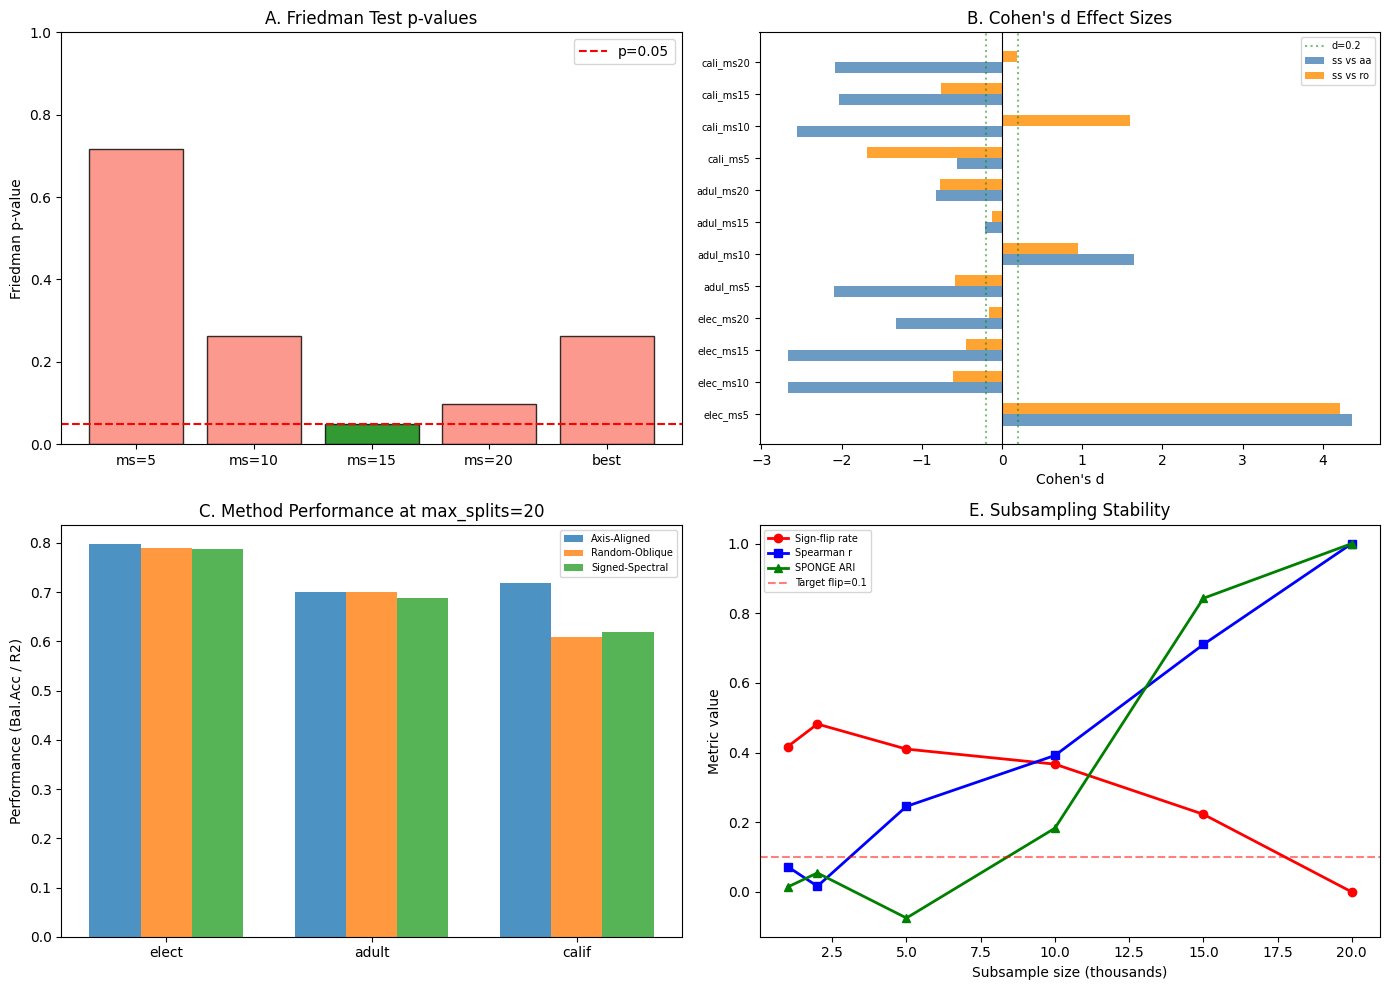

Saved results_summary.png

EVALUATION SUMMARY
Analysis                            Key Result                         
----------------------------------------------------------------------
A. Friedman (ms=15)                 p=0.0498                           
B. Cohen d (ss vs aa)               2W/0T/10L                          
B. Cohen d (ss vs ro)               3W/3T/6L                           
C. Bayesian ss_vs_aa                inconclusive                       
C. Bayesian ss_vs_ro                practically equivalent             
C. Bayesian ro_vs_aa                inconclusive                       
D. Frustration corr                 rho=-1.0, p=0.0                    
E. Subsampling rec. n               20000                              
F. Arity Wilcoxon                   p=0.0669, ss has lower arity       
I. Success criteria                 4/4 passed                         


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Friedman p-values across max_splits ---
ax = axes[0, 0]
ms_labels = [f"ms={ms}" for ms in MAX_SPLITS_GRID] + ["best"]
p_vals = [friedman_results.get(f"max_splits_{ms}", {}).get("friedman_p", 1.0) for ms in MAX_SPLITS_GRID]
p_vals.append(friedman_results.get("best_max_splits", {}).get("friedman_p", 1.0))
colors = ["green" if p < 0.05 else "salmon" for p in p_vals]
ax.bar(ms_labels, p_vals, color=colors, edgecolor="black", alpha=0.8)
ax.axhline(y=0.05, color="red", linestyle="--", linewidth=1.5, label="p=0.05")
ax.set_ylabel("Friedman p-value")
ax.set_title("A. Friedman Test p-values")
ax.legend()
ax.set_ylim(0, 1.0)

# --- Panel 2: Cohen's d effect sizes ---
ax = axes[0, 1]
d_aa = [e["d_ss_vs_aa"] for e in cohens_d_results["per_dataset_ms"]]
d_ro = [e["d_ss_vs_ro"] for e in cohens_d_results["per_dataset_ms"]]
labels = [f"{e['dataset'][:4]}_ms{e['max_splits']}" for e in cohens_d_results["per_dataset_ms"]]
x = np.arange(len(labels))
width = 0.35
ax.barh(x - width/2, d_aa, width, label="ss vs aa", color="steelblue", alpha=0.8)
ax.barh(x + width/2, d_ro, width, label="ss vs ro", color="darkorange", alpha=0.8)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.axvline(x=0.2, color="green", linestyle=":", alpha=0.5, label="d=0.2")
ax.axvline(x=-0.2, color="green", linestyle=":", alpha=0.5)
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Cohen's d")
ax.set_title("B. Cohen's d Effect Sizes")
ax.legend(fontsize=7)

# --- Panel 3: Method performance at ms=20 ---
ax = axes[1, 0]
ds_labels = [ds[:5] for ds in DATASETS]
aa_perf = [lookup.get((ds, "axis_aligned_figs", 20), {}).get("mean", 0) for ds in DATASETS]
ro_perf = [lookup.get((ds, "random_oblique_figs", 20), {}).get("mean", 0) for ds in DATASETS]
ss_perf = [lookup.get((ds, "signed_spectral_figs", 20), {}).get("mean", 0) for ds in DATASETS]
x = np.arange(len(ds_labels))
width = 0.25
ax.bar(x - width, aa_perf, width, label="Axis-Aligned", color="tab:blue", alpha=0.8)
ax.bar(x, ro_perf, width, label="Random-Oblique", color="tab:orange", alpha=0.8)
ax.bar(x + width, ss_perf, width, label="Signed-Spectral", color="tab:green", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ds_labels)
ax.set_ylabel("Performance (Bal.Acc / R2)")
ax.set_title("C. Method Performance at max_splits=20")
ax.legend(fontsize=7)

# --- Panel 4: Subsampling stability ---
ax = axes[1, 1]
sub_data = subsampling_results["data_points"]
ns_plot = np.array(sub_data["subsample_sizes"]) / 1000
ax.plot(ns_plot, sub_data["sign_flip_rates"], "o-", color="red", label="Sign-flip rate", linewidth=2)
ax.plot(ns_plot, sub_data["spearman_correlations"], "s-", color="blue", label="Spearman r", linewidth=2)
ax.plot(ns_plot, sub_data["sponge_aris"], "^-", color="green", label="SPONGE ARI", linewidth=2)
ax.axhline(y=0.1, color="red", linestyle="--", alpha=0.5, label="Target flip=0.1")
ax.set_xlabel("Subsample size (thousands)")
ax.set_ylabel("Metric value")
ax.set_title("E. Subsampling Stability")
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved results_summary.png")

# --- Summary table ---
print("\n" + "=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"{'Analysis':<35} {'Key Result':<35}")
print("-" * 70)
print(f"{'A. Friedman (ms=15)':<35} {'p=' + str(round(friedman_results.get('max_splits_15', {}).get('friedman_p', -1), 4)):<35}")
wlt = cohens_d_results["win_loss_tie"]
print(f"{'B. Cohen d (ss vs aa)':<35} {str(wlt['ss_vs_aa']['positive']) + 'W/' + str(wlt['ss_vs_aa']['negligible']) + 'T/' + str(wlt['ss_vs_aa']['negative']) + 'L':<35}")
print(f"{'B. Cohen d (ss vs ro)':<35} {str(wlt['ss_vs_ro']['positive']) + 'W/' + str(wlt['ss_vs_ro']['negligible']) + 'T/' + str(wlt['ss_vs_ro']['negative']) + 'L':<35}")
for label in ["ss_vs_aa", "ss_vs_ro", "ro_vs_aa"]:
    r = bayesian_results.get(label, {})
    print(f"{'C. Bayesian ' + label:<35} {r.get('interpretation', 'N/A'):<35}")
frust = frustration_results.get("all_datasets", {})
print(f"{'D. Frustration corr':<35} {'rho=' + str(round(frust.get('spearman_rho', -1), 3)) + ', p=' + str(round(frust.get('p_value', -1), 4)):<35}")
print(f"{'E. Subsampling rec. n':<35} {str(subsampling_results.get('recommended_minimum_n', 'N/A')):<35}")
wa = interpretability_results["wilcoxon_arity"]
print(f"{'F. Arity Wilcoxon':<35} {'p=' + str(round(wa['p_value'], 4)) + ', ' + wa['interpretation']:<35}")
print(f"{'I. Success criteria':<35} {str(success_results['overall_assessment']) + '/4 passed':<35}")
print("=" * 70)